<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_1_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import tensorflow as tf
import numpy as np
import pandas as pd
import io

import matplotlib.pyplot as plt

np.set_printoptions(precision=4)

# Load Files

##From local disk:

In [ ]:
file_2021 = files.upload()
file_2020 = files.upload()

In [ ]:
df_2020 = pd.read_csv(io.BytesIO(file_2020['CARGA_ENERGIA_2021.csv']), sep=';', parse_dates=['din_instante'])
df_2021 = pd.read_csv(io.BytesIO(file_2021['CARGA_ENERGIA_2021.csv']), sep=';', parse_dates=['din_instante'])

## From github:

In [2]:
df_2021 = pd.read_csv('https://raw.githubusercontent.com/marcos-mansur/load-forecast/main/Data/CARGA_ENERGIA_2021.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])
df = df_2021.copy()
df.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,NORTE,2021-01-01,5249.829458
1,NE,NORDESTE,2021-01-01,9828.785917
2,S,SUL,2021-01-01,8564.132540
3,SE,SUDESTE,2021-01-01,32419.959958
4,N,NORTE,2021-01-02,5585.214708


In [ ]:
#df_2020 = pd.read_csv('https://raw.githubusercontent.com/marcos-mansur/load-forecast/main/Data/CARGA_ENERGIA_2020.csv', sep=';', parse_dates=['din_instante'])

###Concat 2020:

In [ ]:
# concat dfs of 2020 and 2021
#df_concat = pd.concat([df_2020,df_2021],axis=0,ignore_index=True)
#df = df_concat[df_concat['nom_subsistema']=='SUDESTE'].reset_index().drop('index',axis=1)
#df.head()

# Initialize constants

In [18]:
# 30 days of validation
split_time = 296
window_size = 7
batch_size = 32
shuffle_buffer = 20
np.random.seed(42)

# Treat data

## Pandas

In [5]:
def treat_data(df,regiao='SUDESTE'):
  # create columns with day of the week, of the month and the month 
  df['Mes'] = df['din_instante'].dt.month
  df['dia semana'] = df['din_instante'].dt.day_name()
  df['dia mes'] = df['din_instante'].dt.day
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # dropa as ultimas 4 linhas que não tem valor de carga
  df.dropna(axis=0, how='any',inplace=True)
  df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
  return df

In [6]:
df = treat_data(df,'SUDESTE')
df.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed,Mes,dia semana,dia mes
0,SE,SUDESTE,2021-01-01,32419.96,1,Friday,1
1,SE,SUDESTE,2021-01-02,33849.02,1,Saturday,2
2,SE,SUDESTE,2021-01-03,32674.56,1,Sunday,3
3,SE,SUDESTE,2021-01-04,38192.80,1,Monday,4
4,SE,SUDESTE,2021-01-05,40956.48,1,Tuesday,5


In [ ]:
df.info()

In [242]:
df.shape

(326, 7)

# Split train test

In [7]:
# split_time = 296
x_train = df[df['din_instante']>'2020-12-31'][:split_time].copy().reset_index().drop('index',axis=1)
x_valid = df[df['din_instante']>'2020-12-31'][split_time:].copy().reset_index().drop('index',axis=1)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

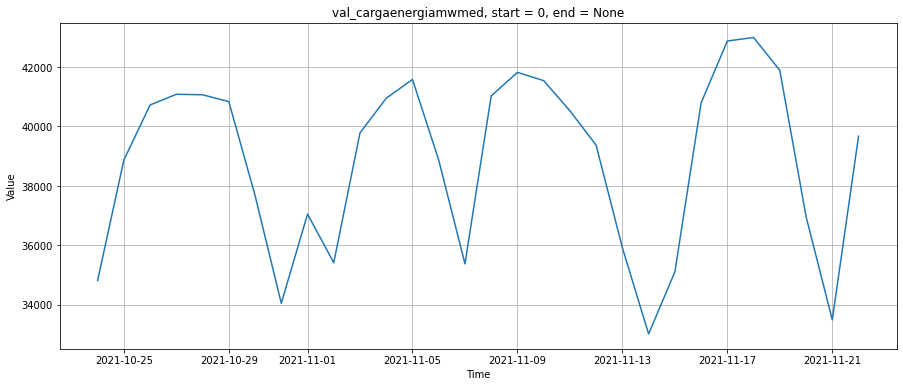

In [8]:
def plot_serie(df1,col='val_cargaenergiamwmed',start=0,end=None, title=''):
  plt.rcParams['figure.figsize'] = [15,6]
  plt.plot(df1['din_instante'][start:end],
           df1[col][start:end],)
  plt.title(title + col + ', start = '+ str(start) + ', end = ' + str(end))
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  return plt


plot_serie(x_valid)

4 peaks in a month, there's definitely weekly sazonality.

# EDA

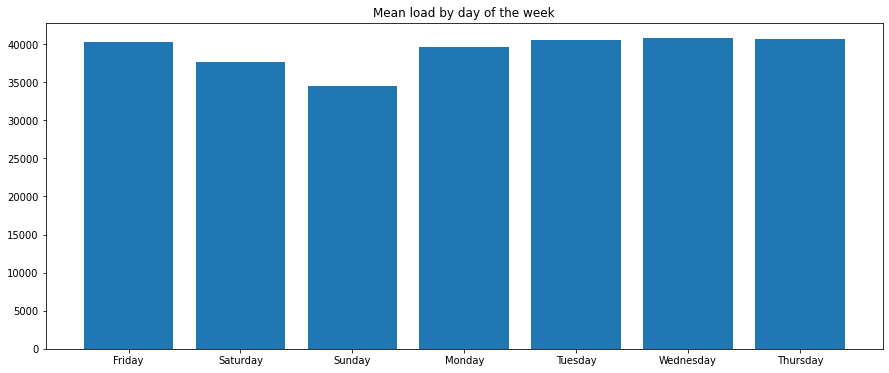

In [200]:
# mean for each day of the week
media_weekd=[]
weekd=[]
for week_day in x_train['dia semana'].unique():
  media_weekd.append(x_train[x_train['dia semana']==week_day]['val_cargaenergiamwmed'].mean())
  weekd.append(week_day)
plt.bar(weekd,media_weekd,)
plt.title('Mean load by day of the week')
plt.show()

Valley on Sundays.

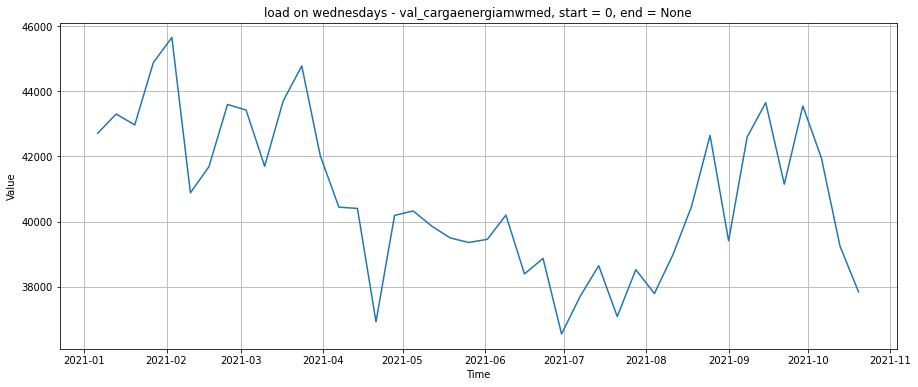

In [56]:
plot_serie(x_train[x_train['dia semana']=='Wednesday'],title='load on wednesdays - ')

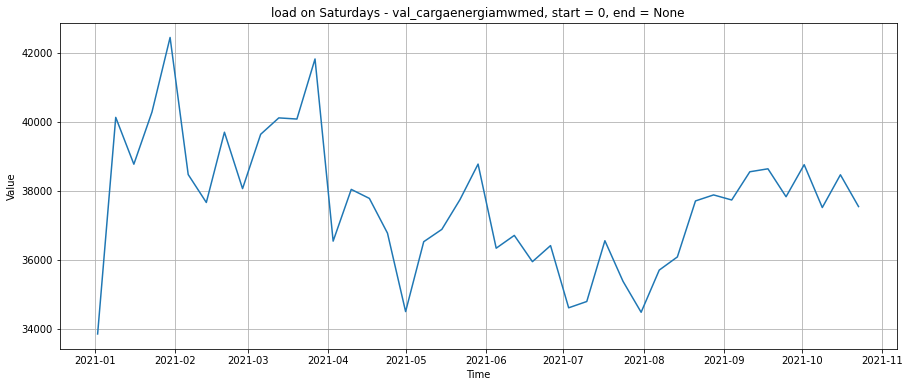

In [57]:
plot_serie(x_train[x_train['dia semana']=='Saturday'],title='load on Saturdays - ')

# TensorFlow Dataset

In [9]:
x_train['val_cargaenergiamwmed'].head()

0    32419.96
1    33849.02
2    32674.56
3    38192.80
4    40956.48
Name: val_cargaenergiamwmed, dtype: float64

Treat the data:

In [10]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
  dataset = dataset.shuffle(shuffle_buffer).map(lambda window: (window[:-1], window[-1]))
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset

dataset = windowed_dataset(x_train['val_cargaenergiamwmed'], window_size, batch_size, shuffle_buffer)

Visualize the data:

In [ ]:
for x,y in dataset:
  print("x = ", x.numpy())
  print("y = ", y.numpy())
  break


# Train the model

In [44]:
# NN layer
l0 = tf.keras.layers.Dense(1, input_shape=[window_size])
# Sequential NN
model = tf.keras.models.Sequential([l0])
# compile
model.compile(loss="mse", optimizer = 'adam')
# train the NN
history = model.fit(dataset,epochs=300,verbose=0)

print("Layer weights {}".format(l0.get_weights()))

Layer weights [array([[ 0.6788],
       [-0.1469],
       [-0.2961],
       [ 0.5073],
       [-0.1544],
       [-0.2491],
       [ 0.6579]], dtype=float32), array([0.0408], dtype=float32)]


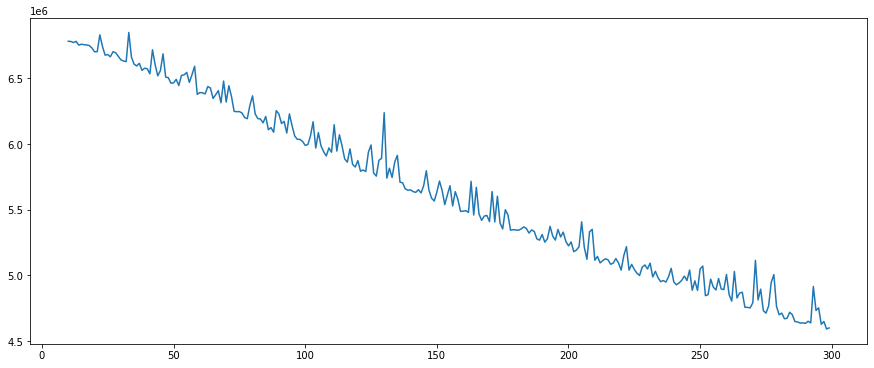

In [46]:
plt.plot(range(10,len(history.history['loss'])),history.history['loss'][10:])

# Prediction

In [47]:
forecast = []

for time in range(len(df) - window_size):
  forecast.append(model.predict(np.array(df['val_cargaenergiamwmed'][time:time + window_size])[np.newaxis]))

forecast = forecast[split_time-window_size:]
results = np.array(forecast)[:, 0, 0]

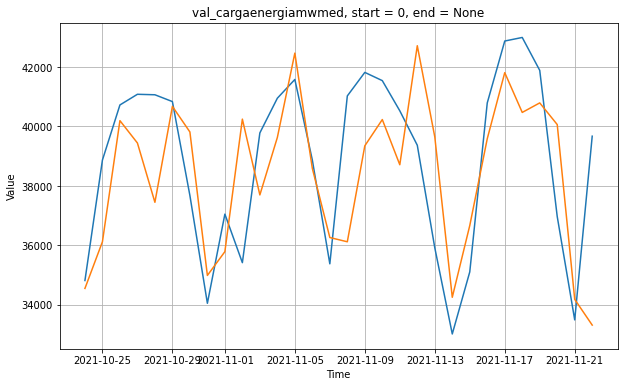

In [48]:
plt.figure(figsize=(10, 6))

plot_serie(x_valid)
plt.plot(x_valid['din_instante'], results)

In [49]:
print('MAE: ',tf.keras.metrics.mean_absolute_error(np.array(x_valid['val_cargaenergiamwmed']), results).numpy())

MAE:  1998.8568
